In [ ]:
!pip install --upgrade langchain langchain-community langgraph openai langchain-openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.0/147.0 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 116.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.9/248.9 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.4/122.4 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 107.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 565.1/565.1 kB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 11.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: openai
    Found e

In [ ]:
from langgraph.graph import StateGraph, START
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import MessagesState
from IPython.display import Image, display
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from typing import Annotated
from typing_extensions import TypedDict


In [ ]:

# from langgraph.graph import MessagesState  Earlier, you created your own state:
# class State(TypedDict):
#     graph_state: str

# But LangGraph provides a pre-built state specifically for handling messages: It is designed for conversations such as:
# User → AI → User → AI → User → AI  MessagesState = a ready-made state structure for storing chat messages.

# add_messages is a message state updater/reducer. Its job is essentially:

# When a new message comes back, add it to the existing list of messages rather than replacing the entire list.

# For example, imagine the state contains:

# messages = [
#     "Hello",
#     "Hi! How can I help?"
# ]

# A new message comes in:"Tell me about EV financing."

# add_messages helps maintain the conversation:

# Hello
# ↓
# Hi! How can I help?
# ↓
# Tell me about EV financing.
# ToolNode is a prebuilt LangGraph node that allows an LLM to execute tools.
# For example, imagine you give your AI these tools:

# calculator
# weather API
# database search
# web search

# The LLM might decide: "I need the calculator." The ToolNode can execute that tool.

# tools_condition This is used for conditional routing.
# ools_condition does something similar, but specifically for deciding:
# Does the LLM want to call a tool, or should we finish/continue normally?

# Annotated allows you to attach additional information/behavior to a type.

        #           LangGraph
        #              │
        #         StateGraph
        #              │
        #              ▼
        #       ┌────────────┐
        #       │    LLM     │
        #       │ ChatOpenAI │
        #       └─────┬──────┘
        #             │
        #      Does it need
        #         a tool?
        #         /      \
        #        /        \
        #      YES         NO
        #       ↓           ↓
        #  ToolNode        END
        #       │
        #       ↓
        #   Tool result
        #       │
        #       └──────→ LLM
 #  And MessagesState / add_messages help maintain the conversation history as the graph moves through these nodes.

In [ ]:
class State(TypedDict):
  messages: Annotated[list, add_messages]

# "My state will contain a field called messages, which is a list of messages.
#Whenever messages are updated, use add_messages to add the new messages to the existing messages."
# Annotated is basically attaching extra information/instructions to the list type.
# "messages is a list, and use add_messages as the way to handle updates to this list."
# Annotated itself does not add messages. It just lets us attach add_messages to the field.
# add messages- "When a node gives me new messages, don't replace my existing messages; merge/add them using add_messages.

In [ ]:
!pip install duckduckgo-search
# That package allows Python code to perform DuckDuckGo web searches.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 115.2 MB/s eta 0:00:00


In [ ]:
from langchain_community.tools import DuckDuckGoSearchResults, DuckDuckGoSearchRun

In [ ]:
!pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 22.0 MB/s eta 0:00:00


In [ ]:
search = DuckDuckGoSearchResults()
search.invoke("Obama's first name?")

'snippet: Barack Hussein Obama II[a] (born August 4, 1961) is an American former politician who served as the 44th president of the United States from 2009 to 2017. A member of the Democratic Party, he was the first African American to serve as president., title: Barack Obama - Wikipedia, link: https://en.wikipedia.org/wiki/Barack_Obama, snippet: Barack Obama, the 44th president of the United States, was born on August 4, 1961, in Honolulu, Hawaii, [1] to Barack Obama, Sr. (1936–1982; born in Oriang\' Kogelo of Rachuonyo North District, [2] Kenya) and Stanley Ann Dunham, known as Ann (1942–1995; born in Wichita, Kansas, United States)., title: Early life and career of Barack Obama - Wikipedia, link: https://en.wikipedia.org/wiki/Early_life_and_career_of_Barack_Obama, snippet: Jan 6, 2026 · The truth is straightforward: Barack Obama has never legally changed his name. He was born Barack Hussein Obama II on August 4, 1961, in Honolulu, Hawaii. This name has remained consistent throughout

In [ ]:
search = DuckDuckGoSearchRun()
search.invoke("Obama's first name?")

'1 day ago - Obama was also a member of the ... a self-named group of friends who spent time together and smoked marijuana. After graduating from high school in 1979, Obama moved to Los Angeles to attend Occidental College on a full scholarship. In February 1981, Obama made his first public speech, ... July 9, 2026 - Obama is a surname. It most commonly refers to Barack Obama (born 1961), the 44th president of the United States. Obama is a common Fang masculine name in western Central Africa. 1 week ago - Barack Hussein Obama II was born on August 4, 1961 in Kapiʻolani Medical Center for Women and Children (called Kapiʻolani Maternity & Gynecological Hospital in 1961) in Honolulu, Hawaii. He is the first President to have been born in Hawaii. His father was a black exchange student from Kenya named ... 5 days ago - Baker subsequently married a Tanzanian man named Ndesandjo and took his surname, as did her sons Mark and David. Mark said in 2009 that Obama had been abusive to him, his la

In [ ]:
search.invoke("who is Narendra Modi?")

'10 hours ago - Narendra Damodardas Modi (born 17 September 1950) is an Indian politician who has served as the prime minister of India since 26 May 2014. Modi was the chief minister of Gujarat from 2001 to 2014 and is the Member of Parliament (MP) for Varanasi. He is a member of the Bharatiya Janata Party ... 3 weeks ago - Narendra Damodardas Modi (born: 17 September, 1950) is an Indian politician who is the 14th and current Prime Minister of the Republic of India since 2014. He was previously the Chief Minister of the state of Gujarat from 2001 to 2014. He was later elected as the prime minister in May 2014. 4 days ago - The timing of raids on the opposition leaders is often made to coincide with elections or other political consequences. According to the data shared by the Union government in the parliament in July 2022, the Enforcement Directorate (ED) has registered 5,422 cases under the Prevention of Money Laundering Act, 2002, but only 23 persons have been convicted – less than 

In [ ]:
from langchain_community.tools import DuckDuckGoSearchRun

def search_duckduckgo(query: str):
  search = DuckDuckGoSearchRun()
  return search.invoke(query)

  # created a function to run the query

In [ ]:
result = search_duckduckgo("What are AI agent?")
print(result)

14 hours ago - Layer 6: Security and compliance – a protective framework for safe operation and compliance with regulatory boundaries. At this layer, security and compliance features embedded into all the AI agent stack layers are integrated together. 3 days ago - In evolutionary systems, a "fitness function" determines which agents are more likely to reproduce. This is analogous to natural selection, where organisms evolve to maximize their chances of survival and reproduction. Some AI systems, such as nearest-neighbor, reason by analogy rather than ... 3 days ago - An artificial intelligence (AI) agent refers to a system or program that is capable of autonomously performing tasks on behalf of a user or another system. 5 days ago - What is AI agents how and why businesses use AI agents, and how to use AI agents with AWS. February 23, 2026 - He defines agentic AI as systems that incorporate multiple, different agents that are orchestrating a task together — for example, a marketplace o

In [ ]:
result = search_duckduckgo("What is Newton's Third Law?")
print(result)

Newton's laws of motion are three physical laws that describe the relationship between the motion of an object and the forces acting on it. These laws, which provide the basis for Newtonian mechanics, can be paraphrased as follows: A body remains at rest, or in motion at a constant speed in a straight line, unless it is acted upon by a force. Inertia, F=ma, and action-reaction — Newton's three laws explained with real-world examples, worked problems, and the misconceptions people get wrong. Learn Newton's Third Law of Motion — its definition, action-reaction pairs, real-world examples, misconceptions, and applications in different fields. Newton's Third Law of Motion states that forces always occur in pairs. When one object exerts a force on another, the second object simultaneously exerts an equal force in the opposite direction on the first object. Statement:- "For every action, there is an equal and opposite reaction." Real-Life Examples of Newton's Third Law of Motion Mathematicall

In [ ]:
from langchain_openai import ChatOpenAI
from getpass import getpass
OPENAI_API_KEY = getpass("Enter your API key here :")

Enter your API key here :··········


In [ ]:
import os
os.environ['OPENAI_API_KEY'] = OPENAI_API_KEY

In [ ]:
llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0)

In [ ]:
llm.invoke("Hello").content

'Hello! How can I assist you today?'

In [ ]:
def add(a: int, b: int) -> int:
  "add a and b"
  return a + b

def multiply(a: int, b: int) -> int:
  "multiply a and b"
  return a * b

In [ ]:
tools = [search_duckduckgo, add, multiply]
llm_with_tools = llm.bind_tools(tools)

# This is the point where you're telling the LLM: "Here are the tools you are allowed to use."
# This does not execute any of the tools.
# It creates a version of your LLM that knows about these tools and can request to use them.
# Original LLM
#      ↓
# bind_tools()
#      ↓
# LLM + knowledge of available tools
#      │
#      ├── search_duckduckgo
#      ├── add
#      └── multiply

In [ ]:
def chatbot(state: State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

  #Take the conversation so far → send it to the LLM → get the LLM's response → add that response to the conversation.
#   State (messages)
#        ↓
#    LLM reads it
#        ↓
# LLM generates response
#        ↓
# Response added to messages
# If the LLM decides a tool is needed, the tool call is included in that response.
#  The actual tool execution happens later through ToolNode.

In [ ]:
from langgraph.prebuilt import ToolNode, tools_condition

In [ ]:
def search_duckduckgo(query: str):
  """Searches DuckDuckGo for the given query.""" # Added docstring here
  search = DuckDuckGoSearchRun()
  return search.invoke(query)

def add(a: int, b: int) -> int:
  """Adds a and b"""
  return a + b

def multiply(a: int, b: int) -> int:
  """Multiply a and b"""
  return a * b

tools = [search_duckduckgo, add, multiply]
llm_with_tools = llm.bind_tools(tools)


def chatbot(state: State):
  return {"messages": [llm_with_tools.invoke(state["messages"])]}

from langgraph.prebuilt import ToolNode, tools_condition

graph_builder = StateGraph(State)

graph_builder.add_node("assistant", chatbot)
graph_builder.add_node("tools", ToolNode(tools))
# Start the graph with the assistant (LLM)
graph_builder.add_edge(START, "assistant")
# Check the LLM response:
# If a tool is requested → go to "tools"
# If no tool is requested → END
graph_builder.add_conditional_edges("assistant", tools_condition)
# After the tool executes, send the result back to the assistant
# so the LLM can generate the final answer
graph_builder.add_edge("tools", "assistant")

react_graph = graph_builder.compile()

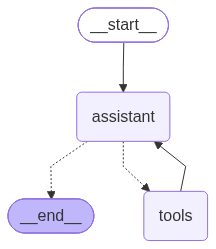

In [ ]:
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [ ]:
response = react_graph.invoke({"messages":[HumanMessage(content="What is the weather in Hydrabad. Multiply it by 2 and add 5.")]})
# "Start my LangGraph with this user's question and run the complete workflow."
# "Run/execute the LangGraph called react_graph with this input."

In [ ]:
response = react_graph.invoke({"messages":[HumanMessage(content="What is the weather in Bangalore. Multiply it by 2 and add 5.")]})

In [ ]:
print(response['messages'])

[HumanMessage(content='What is the weather in Bangalore. Multiply it by 2 and add 5.', additional_kwargs={}, response_metadata={}, id='127e5ef5-0941-4acb-86c4-689b81df042f'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 110, 'total_tokens': 130, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3817d51ca9', 'id': 'chatcmpl-ECMHsqyeWmmLVnwz5bSF5tXwQtbyW', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ffa82-f4d2-7491-91b2-54fa98f27b42-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'current weather in Bangalore'}, 'id': 'call_SQ0M8OIYvGVDmxu6aOskfgRP', 'type': 'too

In [ ]:
response['messages']

[HumanMessage(content='What is the weather in Bangalore. Multiply it by 2 and add 5.', additional_kwargs={}, response_metadata={}, id='127e5ef5-0941-4acb-86c4-689b81df042f'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 110, 'total_tokens': 130, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_3817d51ca9', 'id': 'chatcmpl-ECMHsqyeWmmLVnwz5bSF5tXwQtbyW', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ffa82-f4d2-7491-91b2-54fa98f27b42-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'current weather in Bangalore'}, 'id': 'call_SQ0M8OIYvGVDmxu6aOskfgRP', 'type': 'to